# Duration Prediction Model Comparison
## Cell 1: Environment Setup



In [1]:
# Mount Google Drive
from google.colab import drive
import os
import numpy as np
from sklearn.utils import check_random_state

drive.mount('/content/drive', force_remount=True)

# Path Configuration
PROJECT_PATH = '/content/drive/MyDrive/RL_Predictor_Project'
RAW_DATA_PATH = os.path.join(PROJECT_PATH, '01_Data_Raw')
PROCESSED_PATH = os.path.join(PROJECT_PATH, '02_Data_Processed')
MODEL_PATH = os.path.join(PROJECT_PATH, '04_Models')
VISUAL_PATH = os.path.join(PROJECT_PATH, '05_Visuals')
RESULTS_PATH = os.path.join(PROJECT_PATH, '06_Results')

for path in [MODEL_PATH, VISUAL_PATH, RESULTS_PATH]:
    os.makedirs(path, exist_ok=True)
    print(f"Directory ready: {path}")

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print(f"\nEnvironment setup complete!")
print(f"Project root: {PROJECT_PATH}")
print(f"Random state: {RANDOM_STATE}")

Mounted at /content/drive
Directory ready: /content/drive/MyDrive/RL_Predictor_Project/04_Models
Directory ready: /content/drive/MyDrive/RL_Predictor_Project/05_Visuals
Directory ready: /content/drive/MyDrive/RL_Predictor_Project/06_Results

Environment setup complete!
Project root: /content/drive/MyDrive/RL_Predictor_Project
Random state: 42


## Cell 2: Library Imports



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
from datetime import datetime

# Sklearn imports
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    LabelEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import KFold, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Suppress warnings
warnings.filterwarnings('ignore')

print("All imports successful!")
print(f"Pandas version: {pd.__version__}")
print(f"Numpy version: {np.__version__}")
print(f"Scikit-learn imported successfully")

All imports successful!
Pandas version: 2.2.2
Numpy version: 2.0.2
Scikit-learn imported successfully


## Cell 3: Configuration Settings



In [3]:
# RQ1: Duration Prediction Configuration

CONFIG = {

    'data_file': 'master_data.csv',
    'target_column': 'training_duration_seconds',


    'drop_columns': [
        'training_duration_seconds',
        'timestamp',
        'steps',
        'peak_ram_mb',
        'final_mean_reward',
    ],


    'use_log_transform': True,



    'cv_folds': 5,
    'cv_shuffle': True,
    'cv_random_state': RANDOM_STATE,
    'use_stratified': True,
    'stratify_bins': 10,


    'save_models': True,
    'save_plots': True,
    'save_results': True,
    'verbose': True,
}


print("RQ1: Training Duration Prediction - Experiment Configuration")
print(f"Target: {CONFIG['target_column']}")
print(f"Dataset: {CONFIG['data_file']}")
print(f"Cross-Validation: {CONFIG['cv_folds']}-fold {'Stratified' if CONFIG['use_stratified'] else 'Standard'}")
print(f"Transform: {'Log(seconds)' if CONFIG['use_log_transform'] else 'Raw seconds'}")
print(f"Saving: Models={CONFIG['save_models']}, Plots={CONFIG['save_plots']}, Results={CONFIG['save_results']}")

print("Configuration loaded successfully!")

RQ1: Training Duration Prediction - Experiment Configuration
Target: training_duration_seconds
Dataset: master_data.csv
Cross-Validation: 5-fold Stratified
Transform: Log(seconds)
Saving: Models=True, Plots=True, Results=True
Configuration loaded successfully!


## Cell 4: Data Loading & Initial Cleaning



In [4]:
# Load Data
print("Loading data from:", PROCESSED_PATH)
data_path = os.path.join(PROCESSED_PATH, CONFIG['data_file'])

df = pd.read_csv(data_path)
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")

# Filter for PPO algorithm and cleanup
df = df[df['algorithm'] == 'ppo'].copy()
df = df.dropna(subset=['training_duration_seconds', 'steps'])
CONFIG['drop_columns'].append('algorithm')

# Clean Target Variable
print("\nCleaning target variable:", CONFIG['target_column'])

# Convert to numeric
df[CONFIG['target_column']] = pd.to_numeric(
    df[CONFIG['target_column']],
    errors='coerce'
)

# Count and remove invalid targets
n_missing = df[CONFIG['target_column']].isna().sum()
if n_missing > 0:
    print(f"Found {n_missing} rows with missing/invalid duration")
    df = df.dropna(subset=[CONFIG['target_column']])
    print(f"Removed invalid rows, {len(df)} rows remaining")

# Data Inspection
print("\nData Summary")
print(f"\nDataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")

# Target statistics
print(f"\nTarget Variable: {CONFIG['target_column']}")
print(f"  Min duration:    {df[CONFIG['target_column']].min():.2f} seconds ({df[CONFIG['target_column']].min()/60:.1f} min)")
print(f"  Max duration:    {df[CONFIG['target_column']].max():.2f} seconds ({df[CONFIG['target_column']].max()/3600:.1f} hr)")
print(f"  Mean duration:   {df[CONFIG['target_column']].mean():.2f} seconds ({df[CONFIG['target_column']].mean()/60:.1f} min)")
print(f"  Median duration: {df[CONFIG['target_column']].median():.2f} seconds ({df[CONFIG['target_column']].median()/60:.1f} min)")
print(f"  Std deviation:   {df[CONFIG['target_column']].std():.2f} seconds")

# Feature type breakdown
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = df.select_dtypes(include=['number']).columns.tolist()

print(f"\nFeature Types:")
print(f"  Categorical: {len(cat_cols)} features")
print(f"  Numeric:     {len(num_cols)} features")

# Missing value summary
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print(f"\nMissing Values Found in {len(missing)} columns:")
    for col, count in missing.items():
        pct = 100 * count / len(df)
        print(f"  {col:30s}: {count:4d} ({pct:5.2f}%)")
else:
    print(f"\nNo missing values in dataset")

# Sample rows
print(f"\nFirst 3 rows:")
print(df.head(3))

print("\nData loaded and inspected successfully!")

Loading data from: /content/drive/MyDrive/RL_Predictor_Project/02_Data_Processed
Loaded 5801 rows, 24 columns

Cleaning target variable: training_duration_seconds

Data Summary

Dataset Shape: 5673 rows x 24 columns

Target Variable: training_duration_seconds
  Min duration:    5.25 seconds (0.1 min)
  Max duration:    70605.04 seconds (19.6 hr)
  Mean duration:   568.03 seconds (9.5 min)
  Median duration: 247.41 seconds (4.1 min)
  Std deviation:   1878.33 seconds

Feature Types:
  Categorical: 4 features
  Numeric:     19 features

Missing Values Found in 1 columns:
  final_mean_reward             :   41 ( 0.72%)

First 3 rows:
  enviroment algorithm  learning_rate  batch_size  hidden_units  num_layers  \
0     3DBall       ppo       0.000596          64           834           1   
1     3DBall       ppo       0.000998         128           638           4   
2     3DBall       ppo       0.000184         512           230           1   

    steps  max_steps     ram_gb  cpu_cores  

## Cell 5: Preprocessing Builder Function



In [5]:
# Preprocessing Builder Function

def build_preprocessor(model_type='tree'):
    """
    Build appropriate preprocessing pipeline based on model family.

    Parameters:
    model_type : str, one of {'tree', 'linear', 'distance'}

    Returns:
    preprocessor : ColumnTransformer
    """

    # Identify column types from the full dataset
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    num_cols = df.select_dtypes(include=['number']).columns.tolist()

    # Remove target and drop columns from feature lists
    for col in CONFIG['drop_columns']:
        if col in cat_cols:
            cat_cols.remove(col)
        if col in num_cols:
            num_cols.remove(col)

    # Tree-Based Preprocessing
    if model_type == 'tree':
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', SimpleImputer(strategy='median'), num_cols),
                ('cat', Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OrdinalEncoder(
                        handle_unknown='use_encoded_value',
                        unknown_value=-1
                    ))
                ]), cat_cols)
            ],
            remainder='drop'
        )

    # Linear Model Preprocessing
    elif model_type == 'linear':
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]), num_cols),
                ('cat', Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(
                        handle_unknown='ignore',
                        sparse_output=False
                    ))
                ]), cat_cols)
            ],
            remainder='drop'
        )

    # Distance-Based Preprocessing
    elif model_type == 'distance':
        preprocessor = ColumnTransformer(
            transformers=[
                ('num', Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='median')),
                    ('scaler', StandardScaler())
                ]), num_cols),
                ('cat', Pipeline(steps=[
                    ('imputer', SimpleImputer(strategy='most_frequent')),
                    ('encoder', OneHotEncoder(
                        handle_unknown='ignore',
                        sparse_output=False
                    ))
                ]), cat_cols)
            ],
            remainder='drop'
        )

    else:
        raise ValueError(f"Unknown model_type: {model_type}. Use 'tree', 'linear', or 'distance'")

    return preprocessor


# Test the Function
print("Testing preprocessor builder...\n")

for mtype in ['tree', 'linear', 'distance']:
    prep = build_preprocessor(model_type=mtype)
    print(f"{mtype:10s} preprocessor created successfully")

print("\nPreprocessing builder function ready!")

Testing preprocessor builder...

tree       preprocessor created successfully
linear     preprocessor created successfully
distance   preprocessor created successfully

Preprocessing builder function ready!


## Cell 6: Cross-Validation Training Function



In [6]:
def train_with_cv(model, model_name, preprocessing_type='tree'):
    if CONFIG['verbose']:
        print(f"\n{'='*70}")
        print(f"Training: {model_name}")
        print(f"{'='*70}")

    X = df.drop(columns=[c for c in CONFIG['drop_columns'] if c in df.columns])
    y = df[CONFIG['target_column']].astype(float)

    if CONFIG['use_log_transform']:
        y_transformed = np.log1p(y)
        if CONFIG['verbose']:
            print(f"Target: log1p(seconds)")
    else:
        y_transformed = y.copy()
        if CONFIG['verbose']:
            print(f"Target: raw seconds")

    if CONFIG['use_stratified']:
        y_bins = pd.qcut(
            y,
            q=CONFIG['stratify_bins'],
            labels=False,
            duplicates='drop'
        )
        kf = StratifiedKFold(
            n_splits=CONFIG['cv_folds'],
            shuffle=CONFIG['cv_shuffle'],
            random_state=CONFIG['cv_random_state']
        )
        splits = kf.split(X, y_bins)
        if CONFIG['verbose']:
            print(f"CV: {CONFIG['cv_folds']}-Fold Stratified")
    else:
        kf = KFold(
            n_splits=CONFIG['cv_folds'],
            shuffle=CONFIG['cv_shuffle'],
            random_state=CONFIG['cv_random_state']
        )
        splits = kf.split(X)
        if CONFIG['verbose']:
            print(f"CV: {CONFIG['cv_folds']}-Fold Standard")

    fold_maes = []
    fold_r2s = []

    for fold, (train_idx, test_idx) in enumerate(splits, start=1):
        X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
        y_train, y_test = y_transformed.iloc[train_idx], y_transformed.iloc[test_idx]

        preprocessor = build_preprocessor(model_type=preprocessing_type)
        X_train_transformed = preprocessor.fit_transform(X_train)
        X_test_transformed = preprocessor.transform(X_test)

        model.fit(X_train_transformed, y_train)

        y_pred = model.predict(X_test_transformed)

        if CONFIG['use_log_transform']:
            y_test_real = np.expm1(y_test)
            y_pred_real = np.expm1(y_pred)
        else:
            y_test_real = y_test
            y_pred_real = y_pred

        mae = mean_absolute_error(y_test_real, y_pred_real)
        r2 = r2_score(y_test_real, y_pred_real)
        r2_log = r2_score(y_test, y_pred)

        fold_maes.append(mae)
        fold_r2s.append(r2)

        if CONFIG['verbose']:
            print(f"  Fold {fold}: MAE={mae:7.2f}s | R2={r2:.4f}")

    results = {
        'model_name': model_name,
        'preprocessing': preprocessing_type,
        'avg_mae': float(np.mean(fold_maes)),
        'std_mae': float(np.std(fold_maes)),
        'avg_r2': float(np.mean(fold_r2s)),
        'std_r2': float(np.std(fold_r2s)),
        'fold_maes': fold_maes,
        'fold_r2s': fold_r2s
    }

    if CONFIG['verbose']:
        print(f"  {'─'*66}")
        print(f"  AVERAGE: MAE={results['avg_mae']:7.2f}s (+-{results['std_mae']:.2f}) | R2={results['avg_r2']:.4f} (+-{results['std_r2']:.4f})")

    return results

print("Testing CV training function with a simple model...\n")

test_model = LinearRegression()
test_results = train_with_cv(
    model=test_model,
    model_name="Test: LinearRegression",
    preprocessing_type='linear'
)

print("\n" + "=" * 70)
print("Cross-validation training function ready!")
print("=" * 70)

Testing CV training function with a simple model...


Training: Test: LinearRegression
Target: log1p(seconds)
CV: 5-Fold Stratified
  Fold 1: MAE= 324.46s | R2=0.1954
  Fold 2: MAE= 342.09s | R2=0.0965
  Fold 3: MAE= 271.14s | R2=0.0423
  Fold 4: MAE= 254.94s | R2=-0.4977
  Fold 5: MAE= 209.70s | R2=0.2848
  ──────────────────────────────────────────────────────────────────
  AVERAGE: MAE= 280.46s (+-47.92) | R2=0.0243 (+-0.2739)

Cross-validation training function ready!


## Cell 7: Model Saving Function



In [7]:
def save_model(model, model_name, preprocessing_type, cv_results):
    if not CONFIG['save_models']:
        print(f"Skipping save (CONFIG['save_models']=False)")
        return None

    print(f"\nSaving model: {model_name}")

    X_full = df.drop(columns=[c for c in CONFIG['drop_columns'] if c in df.columns])
    y_full = df[CONFIG['target_column']].astype(float)

    if CONFIG['use_log_transform']:
        y_full_transformed = np.log1p(y_full)
    else:
        y_full_transformed = y_full.copy()

    preprocessor = build_preprocessor(model_type=preprocessing_type)
    X_full_transformed = preprocessor.fit_transform(X_full)

    print(f"  Preprocessor fitted on {len(X_full)} samples")

    model.fit(X_full_transformed, y_full_transformed)
    print(f"  Model trained on full dataset")

    metadata = {
        'model_name': model_name,
        'model_type': type(model).__name__,
        'preprocessing_type': preprocessing_type,
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'n_samples': len(df),
        'n_features': X_full.shape[1],
        'target_transform': 'log1p' if CONFIG['use_log_transform'] else 'none',
        'cv_folds': CONFIG['cv_folds'],
        'cv_avg_mae': cv_results['avg_mae'],
        'cv_std_mae': cv_results['std_mae'],
        'cv_avg_r2': cv_results['avg_r2'],
        'cv_std_r2': cv_results['std_r2'],
        'random_state': CONFIG['cv_random_state'],
        'categorical_columns': df.select_dtypes(include=['object']).columns.tolist(),
        'numeric_columns': df.select_dtypes(include=['number']).columns.tolist(),
    }

    bundle = {
        'model': model,
        'preprocessor': preprocessor,
        'metadata': metadata,
        'config': CONFIG.copy()
    }

    safe_name = model_name.lower().replace(' ', '_').replace(':', '').replace('(', '').replace(')', '')
    timestamp = datetime.now().strftime('%Y%m%d')
    filename = f"duration_model_{safe_name}_{timestamp}.pkl"
    save_path = os.path.join(MODEL_PATH, filename)

    joblib.dump(bundle, save_path)

    file_size_mb = os.path.getsize(save_path) / (1024 * 1024)

    print(f"  Saved to: {filename}")
    print(f"  File size: {file_size_mb:.2f} MB")
    print(f"  CV Performance: MAE={cv_results['avg_mae']:.2f}s, R2={cv_results['avg_r2']:.4f}")

    return save_path

print("Testing model saving function...\n")

if 'test_results' in locals():
    test_save_path = save_model(
        model=LinearRegression(),
        model_name="Test_LinearRegression",
        preprocessing_type='linear',
        cv_results=test_results
    )

    if test_save_path:
        loaded_bundle = joblib.load(test_save_path)
        print(f"\n  Verification: Model loaded successfully")
        print(f"  Bundle contains: {list(loaded_bundle.keys())}")

print("\n" + "=" * 70)
print("Model saving function ready!")
print("=" * 70)

Testing model saving function...


Saving model: Test_LinearRegression
  Preprocessor fitted on 5673 samples
  Model trained on full dataset
  Saved to: duration_model_test_linearregression_20260121.pkl
  File size: 0.01 MB
  CV Performance: MAE=280.46s, R2=0.0243

  Verification: Model loaded successfully
  Bundle contains: ['model', 'preprocessor', 'metadata', 'config']

Model saving function ready!


## Cell 8: Model Registry


In [8]:
MODEL_REGISTRY = [
    {
        'model': LinearRegression(),
        'name': 'Linear Regression',
        'preprocessing': 'linear',
        'description': 'Baseline: Simple linear model, no regularization'
    },
    {
        'model': Ridge(alpha=1.0, random_state=RANDOM_STATE),
        'name': 'Ridge (alpha=1.0)',
        'preprocessing': 'linear',
        'description': 'Linear with L2 regularization, reduces overfitting'
    },
    {
        'model': RandomForestRegressor(
            n_estimators=800,
            max_depth=30,
            min_samples_leaf=2,
            max_features=1.0,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'name': 'Random Forest (tuned)',
        'preprocessing': 'tree',
        'description': 'Tuned RF: 800 trees, depth=30, proven strong performance'
    },
    {
        'model': ExtraTreesRegressor(
            n_estimators=500,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        'name': 'Extra Trees',
        'preprocessing': 'tree',
        'description': 'More randomized splits than RF, often faster'
    },
    {
        'model': GradientBoostingRegressor(
            random_state=RANDOM_STATE
        ),
        'name': 'Gradient Boosting (default)',
        'preprocessing': 'tree',
        'description': 'Sequential boosting, learns from residuals'
    },
    {
        'model': HistGradientBoostingRegressor(
            random_state=RANDOM_STATE
        ),
        'name': 'HistGradientBoosting (default)',
        'preprocessing': 'tree',
        'description': 'Histogram-based GB, faster on large datasets'
    },
    {
        'model': HistGradientBoostingRegressor(
            learning_rate=0.1,
            max_depth=4,
            max_leaf_nodes=63,
            min_samples_leaf=20,
            l2_regularization=3.0,
            random_state=RANDOM_STATE
        ),
        'name': 'HistGradientBoosting (tuned)',
        'preprocessing': 'tree',
        'description': 'Your best model from previous experiments (R2=0.9455)'
    },
    {
        'model': KNeighborsRegressor(
            n_neighbors=5,
            weights='distance'
        ),
        'name': 'KNN (k=5, distance-weighted)',
        'preprocessing': 'distance',
        'description': 'Non-parametric, uses similar training runs'
    },
    {
        'model': KNeighborsRegressor(
            n_neighbors=9,
            weights='distance'
        ),
        'name': 'KNN (k=9, distance-weighted)',
        'preprocessing': 'distance',
        'description': 'Larger neighborhood for smoother predictions'
    },
]

print("=" * 70)
print("MODEL REGISTRY - RQ1: Duration Prediction")
print("=" * 70)
print(f"\nTotal models to train: {len(MODEL_REGISTRY)}\n")

for i, entry in enumerate(MODEL_REGISTRY, start=1):
    print(f"{i}. {entry['name']}")
    print(f"   Type: {type(entry['model']).__name__}")
    print(f"   Preprocessing: {entry['preprocessing']}")
    print(f"   Description: {entry['description']}")
    print()

print("=" * 70)
print("Model registry loaded successfully!")
print("=" * 70)

required_keys = {'model', 'name', 'preprocessing', 'description'}
for i, entry in enumerate(MODEL_REGISTRY, start=1):
    missing_keys = required_keys - set(entry.keys())
    if missing_keys:
        print(f"Warning: Entry {i} missing keys: {missing_keys}")

valid_preprocessing = {'tree', 'linear', 'distance'}
for entry in MODEL_REGISTRY:
    if entry['preprocessing'] not in valid_preprocessing:
        print(f"Warning: Invalid preprocessing type '{entry['preprocessing']}' in {entry['name']}")

MODEL REGISTRY - RQ1: Duration Prediction

Total models to train: 9

1. Linear Regression
   Type: LinearRegression
   Preprocessing: linear
   Description: Baseline: Simple linear model, no regularization

2. Ridge (alpha=1.0)
   Type: Ridge
   Preprocessing: linear
   Description: Linear with L2 regularization, reduces overfitting

3. Random Forest (tuned)
   Type: RandomForestRegressor
   Preprocessing: tree
   Description: Tuned RF: 800 trees, depth=30, proven strong performance

4. Extra Trees
   Type: ExtraTreesRegressor
   Preprocessing: tree
   Description: More randomized splits than RF, often faster

5. Gradient Boosting (default)
   Type: GradientBoostingRegressor
   Preprocessing: tree
   Description: Sequential boosting, learns from residuals

6. HistGradientBoosting (default)
   Type: HistGradientBoostingRegressor
   Preprocessing: tree
   Description: Histogram-based GB, faster on large datasets

7. HistGradientBoosting (tuned)
   Type: HistGradientBoostingRegressor
   P

## Cell 9: Execute Training Loop


In [9]:
import time

print("=" * 70)
print("TRAINING ALL MODELS - RQ1: Duration Prediction")
print("=" * 70)
print(f"\nDataset: {len(df)} training runs")
print(f"Cross-validation: {CONFIG['cv_folds']}-fold")
print(f"Models to train: {len(MODEL_REGISTRY)}")
print(f"Estimated time: 5-10 minutes\n")
print("=" * 70)

results_list = []
failed_models = []

start_time = time.time()

for i, model_entry in enumerate(MODEL_REGISTRY, start=1):

    model_start_time = time.time()

    print(f"\n{'='*70}")
    print(f"MODEL {i}/{len(MODEL_REGISTRY)}: {model_entry['name']}")
    print(f"{'='*70}")

    try:
        cv_results = train_with_cv(
            model=model_entry['model'],
            model_name=model_entry['name'],
            preprocessing_type=model_entry['preprocessing']
        )

        cv_results['description'] = model_entry['description']

        results_list.append(cv_results)

        model_elapsed = time.time() - model_start_time

        print(f"\nCompleted in {model_elapsed:.1f} seconds")

        avg_time_per_model = (time.time() - start_time) / i
        remaining_models = len(MODEL_REGISTRY) - i
        est_remaining_time = avg_time_per_model * remaining_models

        if remaining_models > 0:
            print(f"Estimated time remaining: {est_remaining_time/60:.1f} minutes")

    except Exception as e:
        print(f"\nERROR training {model_entry['name']}: {str(e)}")
        failed_models.append({
            'name': model_entry['name'],
            'error': str(e)
        })
        continue

total_elapsed = time.time() - start_time

print("\n" + "=" * 70)
print("TRAINING COMPLETE!")
print("=" * 70)
print(f"\nTotal time: {total_elapsed/60:.2f} minutes")
print(f"Successfully trained: {len(results_list)}/{len(MODEL_REGISTRY)} models")

if failed_models:
    print(f"Failed models: {len(failed_models)}")
    for failed in failed_models:
        print(f"  - {failed['name']}: {failed['error']}")

results_df = pd.DataFrame(results_list)
results_df = results_df.sort_values('avg_r2', ascending=False).reset_index(drop=True)
results_df.insert(0, 'rank', range(1, len(results_df) + 1))

print("\n" + "=" * 70)
print("RESULTS SUMMARY (sorted by R2)")
print("=" * 70)

display_cols = ['rank', 'model_name', 'avg_mae', 'std_mae', 'avg_r2', 'std_r2']
display_df = results_df[display_cols].copy()

display_df['avg_mae'] = display_df['avg_mae'].apply(lambda x: f"{x:.2f}s")
display_df['std_mae'] = display_df['std_mae'].apply(lambda x: f"+-{x:.2f}s")
display_df['avg_r2'] = display_df['avg_r2'].apply(lambda x: f"{x:.4f}")
display_df['std_r2'] = display_df['std_r2'].apply(lambda x: f"+-{x:.4f}")

print(display_df.to_string(index=False))

champion = results_df.iloc[0]

print("\n" + "=" * 70)
print("CHAMPION MODEL")
print("=" * 70)
print(f"Model: {champion['model_name']}")
print(f"MAE:   {champion['avg_mae']:.2f} seconds (+-{champion['std_mae']:.2f})")
print(f"R2:    {champion['avg_r2']:.4f} (+-{champion['std_r2']:.4f})")
print(f"Info:  {champion['description']}")

print(f"\nIn practical terms:")
print(f"  Average prediction error: {champion['avg_mae']/60:.2f} minutes")
print(f"  Model explains {champion['avg_r2']*100:.2f}% of duration variance")

print("\n" + "=" * 70)
print("Results collected successfully!")
print("=" * 70)

TRAINING ALL MODELS - RQ1: Duration Prediction

Dataset: 5673 training runs
Cross-validation: 5-fold
Models to train: 9
Estimated time: 5-10 minutes


MODEL 1/9: Linear Regression

Training: Linear Regression
Target: log1p(seconds)
CV: 5-Fold Stratified
  Fold 1: MAE= 324.46s | R2=0.1954
  Fold 2: MAE= 342.09s | R2=0.0965
  Fold 3: MAE= 271.14s | R2=0.0423
  Fold 4: MAE= 254.94s | R2=-0.4977
  Fold 5: MAE= 209.70s | R2=0.2848
  ──────────────────────────────────────────────────────────────────
  AVERAGE: MAE= 280.46s (+-47.92) | R2=0.0243 (+-0.2739)

Completed in 0.5 seconds
Estimated time remaining: 0.1 minutes

MODEL 2/9: Ridge (alpha=1.0)

Training: Ridge (alpha=1.0)
Target: log1p(seconds)
CV: 5-Fold Stratified
  Fold 1: MAE= 324.98s | R2=0.1954
  Fold 2: MAE= 341.38s | R2=0.0970
  Fold 3: MAE= 271.35s | R2=0.0425
  Fold 4: MAE= 250.25s | R2=-0.3272
  Fold 5: MAE= 209.71s | R2=0.2839
  ──────────────────────────────────────────────────────────────────
  AVERAGE: MAE= 279.53s (+-48.3

## Cell 10: Results Summary & Saving



In [10]:
if CONFIG['save_results']:
    print("=" * 70)
    print("SAVING RESULTS")
    print("=" * 70)

    results_path = os.path.join(RESULTS_PATH, 'rq1_results_comparison.csv')
    results_df.to_csv(results_path, index=False)
    print(f"\nResults saved to: rq1_results_comparison.csv")

    fold_records = []
    for _, row in results_df.iterrows():
        for fold_num, (mae, r2) in enumerate(zip(row['fold_maes'], row['fold_r2s']), start=1):
            fold_records.append({
                'model_name': row['model_name'],
                'fold': fold_num,
                'mae': mae,
                'r2': r2
            })

    fold_df = pd.DataFrame(fold_records)
    fold_path = os.path.join(RESULTS_PATH, 'rq1_fold_details.csv')
    fold_df.to_csv(fold_path, index=False)
    print(f"Fold details saved to: rq1_fold_details.csv")

    metadata_path = os.path.join(RESULTS_PATH, 'rq1_experiment_metadata.txt')

    with open(metadata_path, 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("RQ1: TRAINING DURATION PREDICTION - EXPERIMENT METADATA\n")
        f.write("=" * 70 + "\n\n")

        f.write("EXPERIMENT DETAILS:\n")
        f.write(f"  Training Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"  Total Duration: {total_elapsed/60:.2f} minutes\n")
        f.write(f"  Random State: {RANDOM_STATE}\n\n")

        f.write("DATASET STATISTICS:\n")
        f.write(f"  Total Samples: {len(df)}\n")
        f.write(f"  Target Column: {CONFIG['target_column']}\n")
        f.write(f"  Min Duration: {df[CONFIG['target_column']].min():.2f}s ({df[CONFIG['target_column']].min()/60:.1f} min)\n")
        f.write(f"  Max Duration: {df[CONFIG['target_column']].max():.2f}s ({df[CONFIG['target_column']].max()/3600:.1f} hr)\n")
        f.write(f"  Mean Duration: {df[CONFIG['target_column']].mean():.2f}s ({df[CONFIG['target_column']].mean()/60:.1f} min)\n")
        f.write(f"  Median Duration: {df[CONFIG['target_column']].median():.2f}s ({df[CONFIG['target_column']].median()/60:.1f} min)\n\n")

        f.write("CONFIGURATION:\n")
        f.write(f"  CV Folds: {CONFIG['cv_folds']}\n")
        f.write(f"  Stratified: {CONFIG['use_stratified']}\n")
        f.write(f"  Log Transform: {CONFIG['use_log_transform']}\n")
        f.write(f"  Models Trained: {len(results_list)}\n\n")

        f.write("CHAMPION MODEL:\n")
        f.write(f"  Name: {champion['model_name']}\n")
        f.write(f"  MAE: {champion['avg_mae']:.2f}s (+-{champion['std_mae']:.2f}s)\n")
        f.write(f"  R2: {champion['avg_r2']:.4f} (+-{champion['std_r2']:.4f})\n")
        f.write(f"  Description: {champion['description']}\n\n")

        f.write("TOP 3 MODELS:\n")
        for i, row in results_df.head(3).iterrows():
            f.write(f"  {row['rank']}. {row['model_name']}\n")
            f.write(f"     MAE: {row['avg_mae']:.2f}s (+-{row['std_mae']:.2f}s)\n")
            f.write(f"     R2: {row['avg_r2']:.4f} (+-{row['std_r2']:.4f})\n\n")

    print(f"Metadata saved to: rq1_experiment_metadata.txt")

print("\n" + "=" * 70)
print("STATISTICAL ANALYSIS")
print("=" * 70)

if len(results_df) >= 2:
    rank1_r2 = results_df.iloc[0]['avg_r2']
    rank2_r2 = results_df.iloc[1]['avg_r2']
    r2_gap = rank1_r2 - rank2_r2
    pct_improvement = (r2_gap / rank2_r2) * 100

    print(f"\nChampion vs Runner-up:")
    print(f"  Rank 1: {results_df.iloc[0]['model_name']} (R2={rank1_r2:.4f})")
    print(f"  Rank 2: {results_df.iloc[1]['model_name']} (R2={rank2_r2:.4f})")
    print(f"  Gap: {r2_gap:.4f} ({pct_improvement:.2f}% improvement)")

stability_df = results_df[['model_name', 'std_r2', 'std_mae']].copy()
stability_df = stability_df.sort_values('std_r2')

print(f"\nModel Stability (by R2 variance):")
for i, row in stability_df.head(3).iterrows():
    print(f"  {row['model_name']:40s} std_r2={row['std_r2']:.4f}")

print(f"\nPerformance by Model Family:")

model_families = {
    'Linear': ['Linear Regression', 'Ridge'],
    'Random Forest': ['Random Forest', 'Extra Trees'],
    'Gradient Boosting': ['Gradient Boosting', 'HistGradientBoosting'],
    'Distance-based': ['KNN']
}

for family, keywords in model_families.items():
    family_models = results_df[results_df['model_name'].str.contains('|'.join(keywords), case=False)]
    if len(family_models) > 0:
        avg_r2 = family_models['avg_r2'].mean()
        best_model = family_models.iloc[0]
        print(f"  {family:20s}: avg R2={avg_r2:.4f}, best={best_model['model_name']} (R2={best_model['avg_r2']:.4f})")

print("\n" + "=" * 70)
print("Results saved and analyzed!")
print("=" * 70)

SAVING RESULTS

Results saved to: rq1_results_comparison.csv
Fold details saved to: rq1_fold_details.csv
Metadata saved to: rq1_experiment_metadata.txt

STATISTICAL ANALYSIS

Champion vs Runner-up:
  Rank 1: Gradient Boosting (default) (R2=0.3857)
  Rank 2: HistGradientBoosting (tuned) (R2=0.3755)
  Gap: 0.0103 (2.73% improvement)

Model Stability (by R2 variance):
  KNN (k=9, distance-weighted)             std_r2=0.1363
  KNN (k=5, distance-weighted)             std_r2=0.1380
  HistGradientBoosting (default)           std_r2=0.1909

Performance by Model Family:
  Linear              : avg R2=0.0413, best=Ridge (alpha=1.0) (R2=0.0583)
  Random Forest       : avg R2=0.3422, best=Random Forest (tuned) (R2=0.3492)
  Gradient Boosting   : avg R2=0.3735, best=Gradient Boosting (default) (R2=0.3857)
  Distance-based      : avg R2=0.2003, best=KNN (k=5, distance-weighted) (R2=0.2061)

Results saved and analyzed!


## Cell 11: Visualization - Model Comparison



Saved: rq1_model_comparison_r2.png


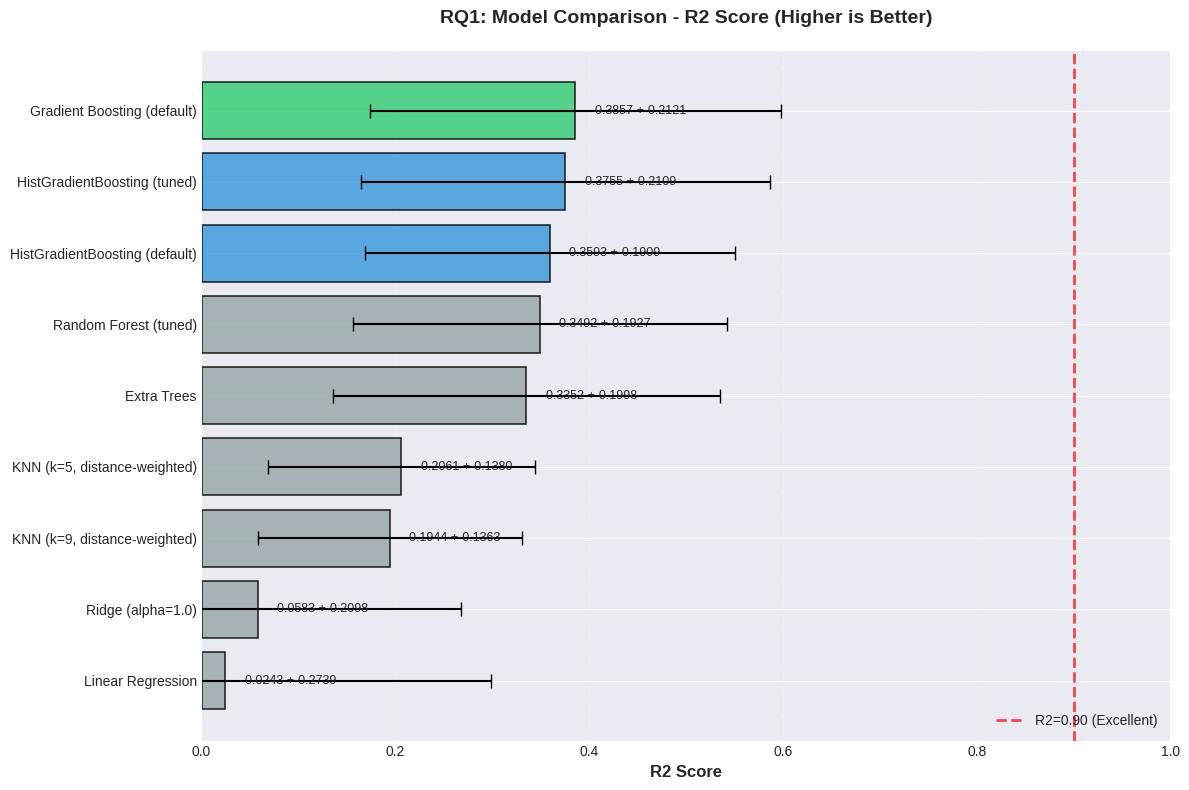

Saved: rq1_model_comparison_mae.png


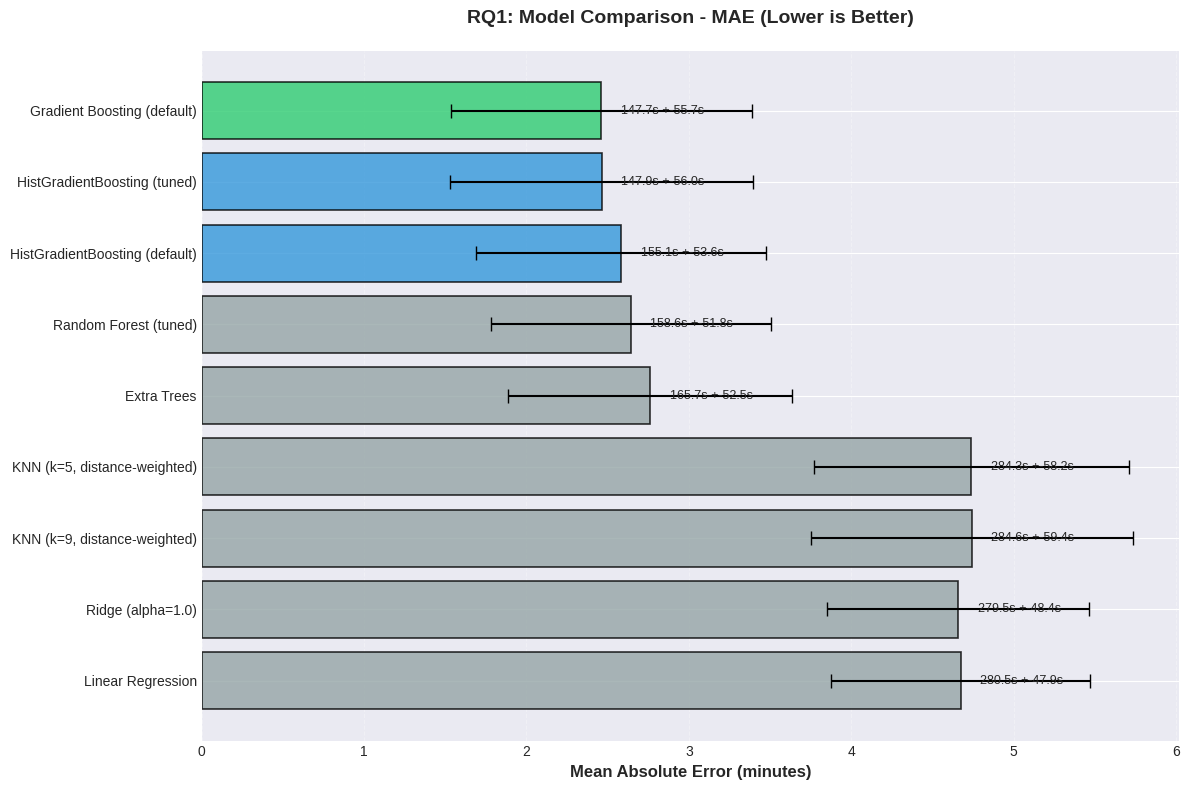

Saved: rq1_model_scatter_r2_vs_mae.png


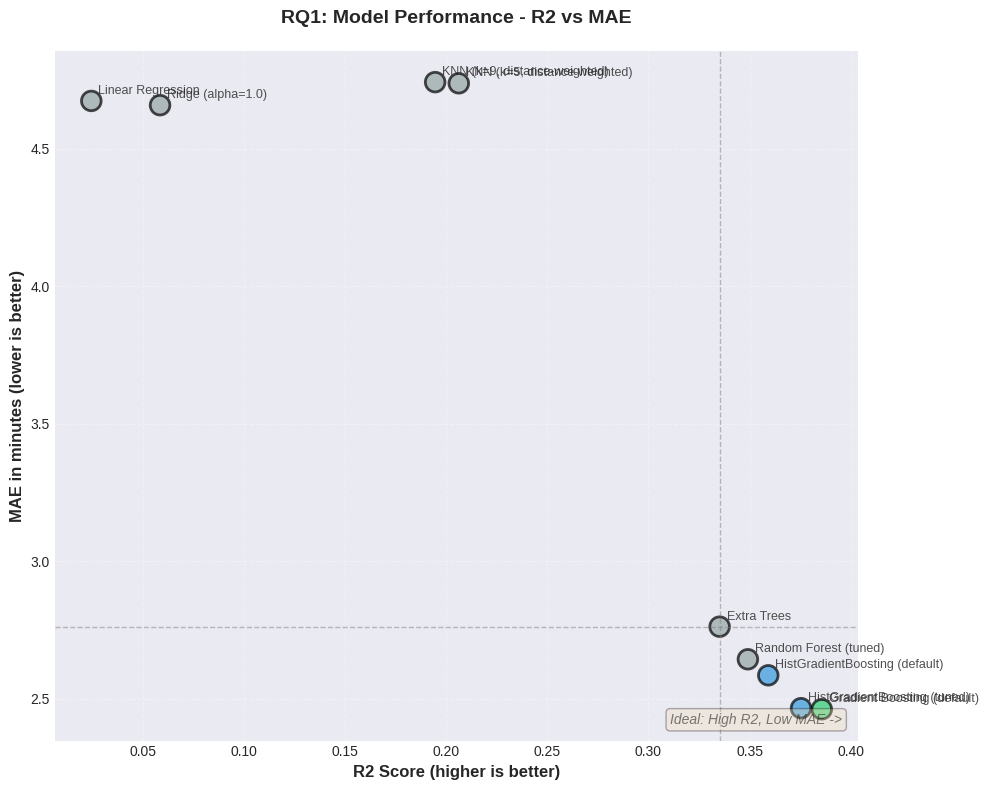


Visualizations created successfully!


In [11]:
fig, ax = plt.subplots(figsize=(12, 8))

models = results_df['model_name'].tolist()
r2_means = results_df['avg_r2'].tolist()
r2_stds = results_df['std_r2'].tolist()

colors = []
for i in range(len(models)):
    if i == 0:
        colors.append('#2ecc71')
    elif i < 3:
        colors.append('#3498db')
    else:
        colors.append('#95a5a6')

y_pos = np.arange(len(models))
bars = ax.barh(y_pos, r2_means, xerr=r2_stds, color=colors,
               alpha=0.8, edgecolor='black', linewidth=1.2, capsize=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(models)
ax.invert_yaxis()
ax.set_xlabel('R2 Score', fontsize=12, fontweight='bold')
ax.set_title('RQ1: Model Comparison - R2 Score (Higher is Better)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlim(0, 1.0)

ax.axvline(x=0.90, color='red', linestyle='--', linewidth=2, alpha=0.7, label='R2=0.90 (Excellent)')

for i, (bar, mean, std) in enumerate(zip(bars, r2_means, r2_stds)):
    width = bar.get_width()
    label_x = width + 0.02
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'{mean:.4f} +-{std:.4f}',
            va='center', ha='left', fontsize=9)

ax.legend(loc='lower right', fontsize=10)

ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()

if CONFIG['save_plots']:
    plot_path = os.path.join(VISUAL_PATH, 'rq1_model_comparison_r2.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved: rq1_model_comparison_r2.png")

plt.show()

fig, ax = plt.subplots(figsize=(12, 8))

mae_means = results_df['avg_mae'].tolist()
mae_stds = results_df['std_mae'].tolist()
mae_means_min = [m/60 for m in mae_means]
mae_stds_min = [s/60 for s in mae_stds]

y_pos = np.arange(len(models))
bars = ax.barh(y_pos, mae_means_min, xerr=mae_stds_min, color=colors,
               alpha=0.8, edgecolor='black', linewidth=1.2, capsize=5)

ax.set_yticks(y_pos)
ax.set_yticklabels(models)
ax.invert_yaxis()
ax.set_xlabel('Mean Absolute Error (minutes)', fontsize=12, fontweight='bold')
ax.set_title('RQ1: Model Comparison - MAE (Lower is Better)',
             fontsize=14, fontweight='bold', pad=20)

for i, (bar, mean_sec, std_sec) in enumerate(zip(bars, mae_means, mae_stds)):
    width = bar.get_width()
    label_x = width + (ax.get_xlim()[1] * 0.02)
    ax.text(label_x, bar.get_y() + bar.get_height()/2,
            f'{mean_sec:.1f}s +-{std_sec:.1f}s',
            va='center', ha='left', fontsize=9)

ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.tight_layout()

if CONFIG['save_plots']:
    plot_path = os.path.join(VISUAL_PATH, 'rq1_model_comparison_mae.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved: rq1_model_comparison_mae.png")

plt.show()

fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(results_df['avg_r2'], results_df['avg_mae']/60,
           s=200, c=colors, alpha=0.7, edgecolors='black', linewidth=2)

for _, row in results_df.iterrows():
    ax.annotate(row['model_name'],
                (row['avg_r2'], row['avg_mae']/60),
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8)

ax.set_xlabel('R2 Score (higher is better)', fontsize=12, fontweight='bold')
ax.set_ylabel('MAE in minutes (lower is better)', fontsize=12, fontweight='bold')
ax.set_title('RQ1: Model Performance - R2 vs MAE',
            fontsize=14, fontweight='bold', pad=20)

median_r2 = results_df['avg_r2'].median()
median_mae = results_df['avg_mae'].median() / 60
ax.axvline(x=median_r2, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.axhline(y=median_mae, color='gray', linestyle='--', alpha=0.5, linewidth=1)

ax.text(0.98, 0.02, 'Ideal: High R2, Low MAE ->',
        transform=ax.transAxes, ha='right', va='bottom',
        fontsize=10, style='italic', alpha=0.6,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()

if CONFIG['save_plots']:
    plot_path = os.path.join(VISUAL_PATH, 'rq1_model_scatter_r2_vs_mae.png')
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    print(f"Saved: rq1_model_scatter_r2_vs_mae.png")

plt.show()

print("\n" + "=" * 70)
print("Visualizations created successfully!")
print("=" * 70)

## Cell 12: Feature Importance Analysis



FEATURE IMPORTANCE ANALYSIS

Analyzing champion model: Gradient Boosting (default)
   Preprocessing type: tree
Champion model retrained on 5673 samples
Total features after preprocessing: 18
Using tree-based feature importances

Top 15 Most Important Features:
----------------------------------------------------------------------
  num__max_steps                                    : 0.790058
  cat__enviroment                                   : 0.101662
  num__ram_gb                                       : 0.065846
  num__num_epoch                                    : 0.012320
  num__gpu_memory_gb                                : 0.006947
  cat__os                                           : 0.005393
  cat__gpu                                          : 0.004825
  num__buffer_size                                  : 0.004773
  num__hidden_units                                 : 0.002179
  num__learning_rate                                : 0.001721
  num__num_layers                     

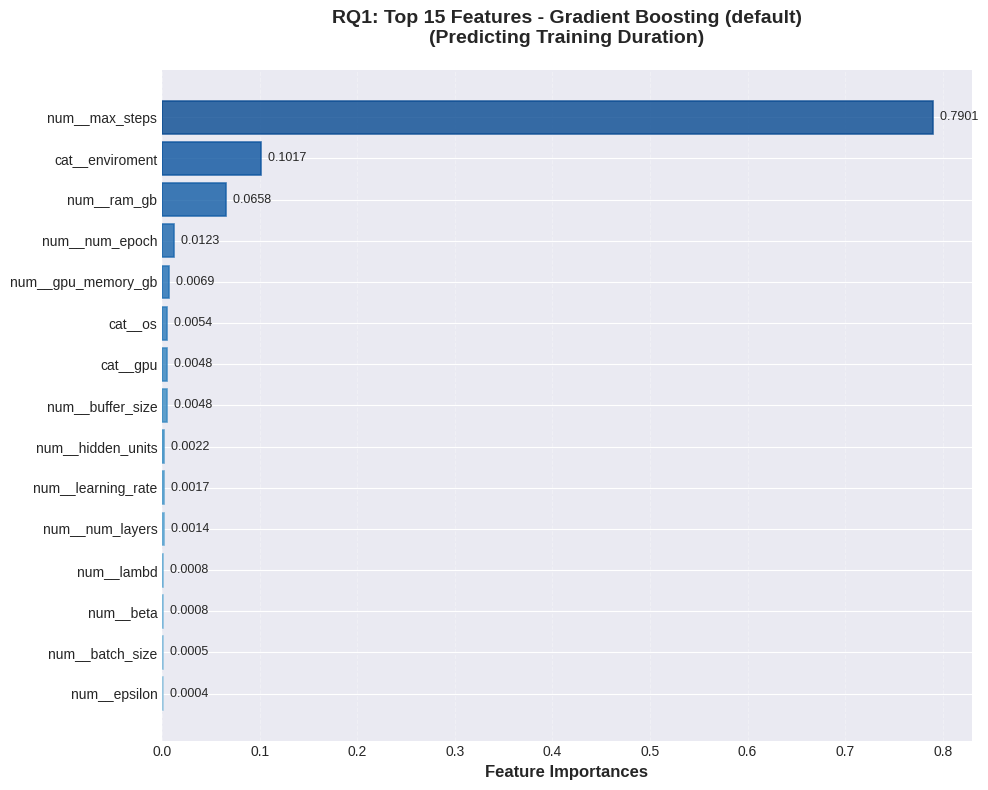

Saved: rq1_feature_importance_gradient_boosting_(default).csv

KEY INSIGHTS

Checking for expected important features:
  Found 'num__max_steps' with importance 0.790058
  'environment' not in top 15 features
  Found 'num__batch_size' with importance 0.000452
  Found 'num__num_layers' with importance 0.001444
  Found 'num__hidden_units' with importance 0.002179

Feature importance analysis complete!


In [12]:
print("=" * 70)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 70)

champion_name = results_df.iloc[0]['model_name']
champion_preprocessing = results_df.iloc[0]['preprocessing']

print(f"\nAnalyzing champion model: {champion_name}")
print(f"   Preprocessing type: {champion_preprocessing}")

champion_model = None
for entry in MODEL_REGISTRY:
    if entry['name'] == champion_name:
        champion_model = entry['model']
        break

if champion_model is None:
    print(f"Could not find champion model in registry")
else:
    X_full = df.drop(columns=[c for c in CONFIG['drop_columns'] if c in df.columns])
    y_full = df[CONFIG['target_column']].astype(float)

    if CONFIG['use_log_transform']:
        y_full_transformed = np.log1p(y_full)
    else:
        y_full_transformed = y_full.copy()

    preprocessor = build_preprocessor(model_type=champion_preprocessing)
    X_full_transformed = preprocessor.fit_transform(X_full)

    champion_model.fit(X_full_transformed, y_full_transformed)

    print(f"Champion model retrained on {len(X_full)} samples")

    try:
        feature_names = preprocessor.get_feature_names_out()
    except AttributeError:
        feature_names = [f"feature_{i}" for i in range(X_full_transformed.shape[1])]

    print(f"Total features after preprocessing: {len(feature_names)}")

    importances = None
    importance_type = None

    if hasattr(champion_model, 'feature_importances_'):
        importances = champion_model.feature_importances_
        importance_type = 'feature_importances'
        print(f"Using tree-based feature importances")

    elif hasattr(champion_model, 'coef_'):
        importances = np.abs(champion_model.coef_)
        importance_type = 'coefficient_magnitude'
        print(f"Using coefficient magnitudes (linear model)")

    else:
        print(f"Model type does not support feature importance extraction")

    if importances is not None:
        importance_df = pd.DataFrame({
            'feature': feature_names,
            'importance': importances
        })

        importance_df = importance_df.sort_values('importance', ascending=True)

        n_top = min(15, len(importance_df))
        top_features = importance_df.tail(n_top)

        print(f"\nTop {n_top} Most Important Features:")
        print("-" * 70)
        for i, row in top_features.iloc[::-1].iterrows():
            print(f"  {row['feature']:50s}: {row['importance']:.6f}")

        fig, ax = plt.subplots(figsize=(10, 8))

        bars = ax.barh(range(len(top_features)), top_features['importance'],
                       color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.2)

        colors_gradient = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_features)))
        for bar, color in zip(bars, colors_gradient):
            bar.set_color(color)

        ax.set_yticks(range(len(top_features)))
        ax.set_yticklabels(top_features['feature'])
        ax.set_xlabel(f'{importance_type.replace("_", " ").title()}',
                      fontsize=12, fontweight='bold')
        ax.set_title(f'RQ1: Top {n_top} Features - {champion_name}\n(Predicting Training Duration)',
                     fontsize=14, fontweight='bold', pad=20)

        for i, (idx, row) in enumerate(top_features.iterrows()):
            ax.text(row['importance'], i, f"  {row['importance']:.4f}",
                    va='center', ha='left', fontsize=9)

        ax.grid(axis='x', alpha=0.3, linestyle='--')

        plt.tight_layout()

        if CONFIG['save_plots']:
            plot_path = os.path.join(VISUAL_PATH, f'rq1_feature_importance_{champion_name.lower().replace(" ", "_")}.png')
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            print(f"\nSaved: rq1_feature_importance_{champion_name.lower().replace(' ', '_')}.png")

        plt.show()

        if CONFIG['save_results']:
            importance_path = os.path.join(RESULTS_PATH, f'rq1_feature_importance_{champion_name.lower().replace(" ", "_")}.csv')
            importance_df.to_csv(importance_path, index=False)
            print(f"Saved: rq1_feature_importance_{champion_name.lower().replace(' ', '_')}.csv")

        print("\n" + "=" * 70)
        print("KEY INSIGHTS")
        print("=" * 70)

        expected_important = ['max_steps', 'environment', 'batch_size', 'num_layers', 'hidden_units']

        print("\nChecking for expected important features:")
        for expected in expected_important:
            matches = [f for f in top_features['feature'] if expected.lower() in f.lower()]
            if matches:
                for match in matches:
                    imp = importance_df[importance_df['feature'] == match]['importance'].values[0]
                    print(f"  Found '{match}' with importance {imp:.6f}")
            else:
                print(f"  '{expected}' not in top {n_top} features")

print("\n" + "=" * 70)
print("Feature importance analysis complete!")
print("=" * 70)

## Cell 13: Champion Model - Detailed Analysis



CHAMPION MODEL - DETAILED ANALYSIS

Model: Gradient Boosting (default)
Performance: MAE=147.68s, R2=0.3857

Full Dataset Performance:
  MAE:  134.51 seconds (2.24 minutes)
  RMSE: 1544.64 seconds (25.74 minutes)
  R2:   0.3236
  R2 (Log-Scale): 0.9684

Saved: rq1_actual_vs_predicted.png


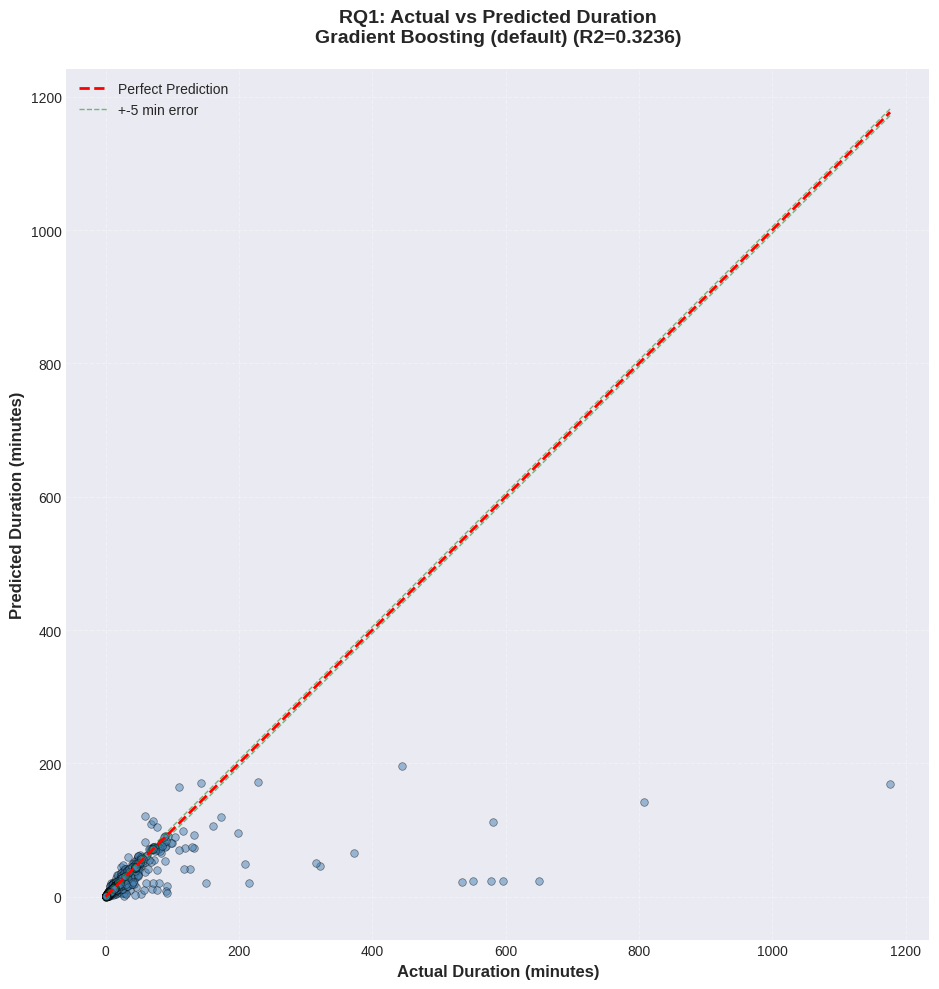

Saved: rq1_residuals.png


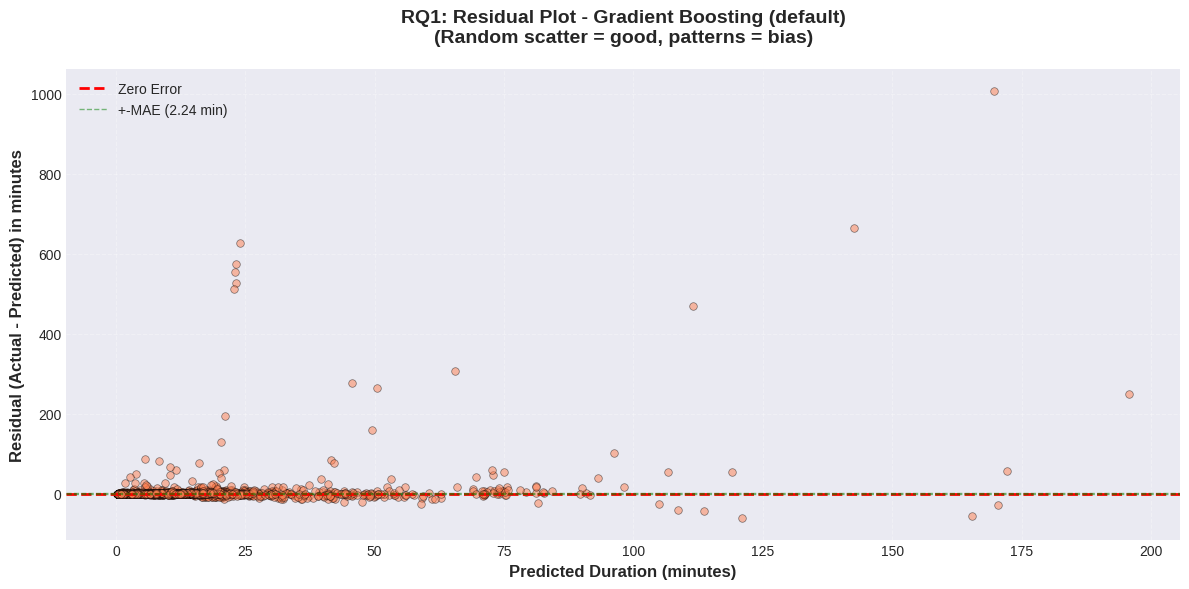

Saved: rq1_error_distribution.png


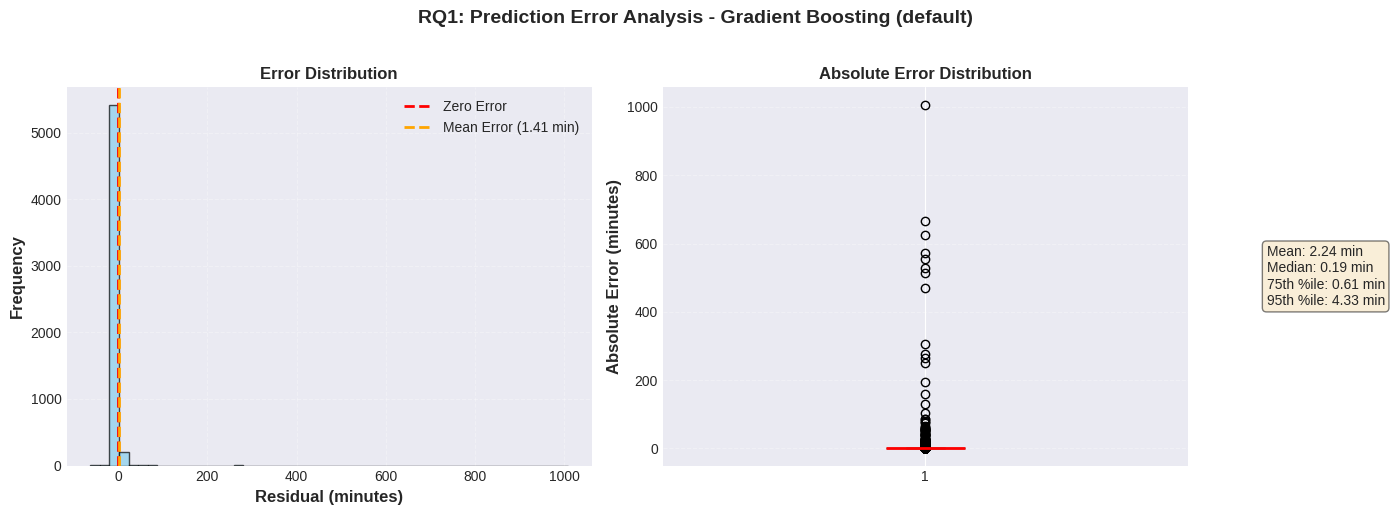


PERFORMANCE BREAKDOWN

Error by Algorithm:
               mean        std  count
algorithm                            
ppo        2.241831  25.648488   5673

Error by Duration Range:
                     mean         std  count
duration_range                              
<5min            0.166189    0.282736   3024
5-15min          0.716030    1.132587   1861
15-30min         2.510306    3.326852    553
30-60min         8.126276    9.685832    147
>60min          94.318846  183.838140     88

Champion model analysis complete!


In [13]:
print("=" * 70)
print("CHAMPION MODEL - DETAILED ANALYSIS")
print("=" * 70)
print(f"\nModel: {champion_name}")
print(f"Performance: MAE={champion['avg_mae']:.2f}s, R2={champion['avg_r2']:.4f}")

X_full = df.drop(columns=[c for c in CONFIG['drop_columns'] if c in df.columns])
y_full = df[CONFIG['target_column']].astype(float)

if CONFIG['use_log_transform']:
    y_full_transformed = np.log1p(y_full)
else:
    y_full_transformed = y_full.copy()

champion_model_final = None
for entry in MODEL_REGISTRY:
    if entry['name'] == champion_name:
        champion_model_final = entry['model']
        break

preprocessor = build_preprocessor(model_type=champion_preprocessing)
X_full_transformed = preprocessor.fit_transform(X_full)
champion_model_final.fit(X_full_transformed, y_full_transformed)

y_pred_transformed = champion_model_final.predict(X_full_transformed)

if CONFIG['use_log_transform']:
    y_actual = np.expm1(y_full_transformed)
    y_pred = np.expm1(y_pred_transformed)
else:
    y_actual = y_full_transformed
    y_pred = y_pred_transformed

mae_full = mean_absolute_error(y_actual, y_pred)
r2_full = r2_score(y_actual, y_pred)
rmse_full = np.sqrt(mean_squared_error(y_actual, y_pred))
r2_log = r2_score(y_full_transformed, y_pred_transformed)

print(f"\nFull Dataset Performance:")
print(f"  MAE:  {mae_full:.2f} seconds ({mae_full/60:.2f} minutes)")
print(f"  RMSE: {rmse_full:.2f} seconds ({rmse_full/60:.2f} minutes)")
print(f"  R2:   {r2_full:.4f}")
print(f"  R2 (Log-Scale): {r2_log:.4f}")

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(y_actual/60, y_pred/60, alpha=0.5, s=30, color='steelblue', edgecolors='black', linewidth=0.5)

min_val = min(y_actual.min(), y_pred.min()) / 60
max_val = max(y_actual.max(), y_pred.max()) / 60
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')

ax.plot([min_val, max_val], [min_val+5, max_val+5], 'g--', linewidth=1, alpha=0.5, label='+-5 min error')
ax.plot([min_val, max_val], [min_val-5, max_val-5], 'g--', linewidth=1, alpha=0.5)

ax.set_xlabel('Actual Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Predicted Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_title(f'RQ1: Actual vs Predicted Duration\n{champion_name} (R2={r2_full:.4f})',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()

if CONFIG['save_plots']:
    plt.savefig(os.path.join(VISUAL_PATH, 'rq1_actual_vs_predicted.png'), dpi=300, bbox_inches='tight')
    print(f"\nSaved: rq1_actual_vs_predicted.png")

plt.show()

residuals = (y_actual - y_pred) / 60

fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(y_pred/60, residuals, alpha=0.5, s=30, color='coral', edgecolors='black', linewidth=0.5)

ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error')

ax.axhline(y=mae_full/60, color='green', linestyle='--', linewidth=1, alpha=0.5, label=f'+-MAE ({mae_full/60:.2f} min)')
ax.axhline(y=-mae_full/60, color='green', linestyle='--', linewidth=1, alpha=0.5)

ax.set_xlabel('Predicted Duration (minutes)', fontsize=12, fontweight='bold')
ax.set_ylabel('Residual (Actual - Predicted) in minutes', fontsize=12, fontweight='bold')
ax.set_title(f'RQ1: Residual Plot - {champion_name}\n(Random scatter = good, patterns = bias)',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper left', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()

if CONFIG['save_plots']:
    plt.savefig(os.path.join(VISUAL_PATH, 'rq1_residuals.png'), dpi=300, bbox_inches='tight')
    print(f"Saved: rq1_residuals.png")

plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(residuals, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax1.axvline(x=residuals.mean(), color='orange', linestyle='--', linewidth=2, label=f'Mean Error ({residuals.mean():.2f} min)')
ax1.set_xlabel('Residual (minutes)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax1.set_title('Error Distribution', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3, linestyle='--')

abs_errors = np.abs(residuals)
ax2.boxplot(abs_errors, vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightgreen', alpha=0.7),
            medianprops=dict(color='red', linewidth=2))
ax2.set_ylabel('Absolute Error (minutes)', fontsize=12, fontweight='bold')
ax2.set_title('Absolute Error Distribution', fontsize=12, fontweight='bold')
ax2.grid(alpha=0.3, linestyle='--', axis='y')

stats_text = f"Mean: {abs_errors.mean():.2f} min\nMedian: {np.median(abs_errors):.2f} min\n75th %ile: {np.percentile(abs_errors, 75):.2f} min\n95th %ile: {np.percentile(abs_errors, 95):.2f} min"
ax2.text(1.15, 0.5, stats_text, transform=ax2.transAxes,
         fontsize=10, verticalalignment='center',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle(f'RQ1: Prediction Error Analysis - {champion_name}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

if CONFIG['save_plots']:
    plt.savefig(os.path.join(VISUAL_PATH, 'rq1_error_distribution.png'), dpi=300, bbox_inches='tight')
    print(f"Saved: rq1_error_distribution.png")

plt.show()

print("\n" + "=" * 70)
print("PERFORMANCE BREAKDOWN")
print("=" * 70)

analysis_df = df.copy()
analysis_df['predicted_duration'] = y_pred
analysis_df['actual_duration'] = y_actual
analysis_df['abs_error_minutes'] = np.abs(y_actual - y_pred) / 60

if 'environment' in analysis_df.columns:
    print("\nError by Environment:")
    env_stats = analysis_df.groupby('environment')['abs_error_minutes'].agg(['mean', 'std', 'count'])
    env_stats = env_stats.sort_values('mean')
    print(env_stats.to_string())

if 'algorithm' in analysis_df.columns:
    print("\nError by Algorithm:")
    algo_stats = analysis_df.groupby('algorithm')['abs_error_minutes'].agg(['mean', 'std', 'count'])
    algo_stats = algo_stats.sort_values('mean')
    print(algo_stats.to_string())

print("\nError by Duration Range:")
duration_bins = pd.cut(analysis_df['actual_duration']/60,
                       bins=[0, 5, 15, 30, 60, float('inf')],
                       labels=['<5min', '5-15min', '15-30min', '30-60min', '>60min'])
analysis_df['duration_range'] = duration_bins
range_stats = analysis_df.groupby('duration_range')['abs_error_minutes'].agg(['mean', 'std', 'count'])
print(range_stats.to_string())

print("\n" + "=" * 70)
print("Champion model analysis complete!")
print("=" * 70)

In [14]:
# ============================================================================
# CONFIGURATION: HOW MANY MODELS TO SAVE
# ============================================================================

N_MODELS_TO_SAVE = 3  # Save top 3 models

print("=" * 70)
print(f"💾 SAVING TOP {N_MODELS_TO_SAVE} MODELS")
print("=" * 70)

# ============================================================================
# SAVE TOP N MODELS
# ============================================================================

saved_models = []

for rank in range(min(N_MODELS_TO_SAVE, len(results_df))):
    model_info = results_df.iloc[rank]

    print(f"\n{'─'*70}")
    print(f"Rank {rank+1}: {model_info['model_name']}")
    print(f"{'─'*70}")

    # Find model in registry
    model_instance = None
    for entry in MODEL_REGISTRY:
        if entry['name'] == model_info['model_name']:
            model_instance = entry['model']
            break

    if model_instance is None:
        print(f"⚠️  Warning: Could not find model in registry, skipping...")
        continue

    # Prepare CV results dict for save_model function
    cv_results = {
        'avg_mae': model_info['avg_mae'],
        'std_mae': model_info['std_mae'],
        'avg_r2': model_info['avg_r2'],
        'std_r2': model_info['std_r2']
    }

    # Save model
    save_path = save_model(
        model=model_instance,
        model_name=model_info['model_name'],
        preprocessing_type=model_info['preprocessing'],
        cv_results=cv_results
    )

    if save_path:
        saved_models.append({
            'rank': rank + 1,
            'name': model_info['model_name'],
            'path': save_path,
            'mae': model_info['avg_mae'],
            'r2': model_info['avg_r2']
        })

# ============================================================================
# CREATE MODEL INVENTORY
# ============================================================================

print("\n" + "=" * 70)
print("📋 SAVED MODELS INVENTORY")
print("=" * 70)

if saved_models:
    inventory_df = pd.DataFrame(saved_models)

    print("\n")
    for _, row in inventory_df.iterrows():
        print(f"Rank {row['rank']}: {row['name']}")
        print(f"  File: {os.path.basename(row['path'])}")
        print(f"  Performance: MAE={row['mae']:.2f}s, R²={row['r2']:.4f}")
        print()

    # Save inventory
    if CONFIG['save_results']:
        inventory_path = os.path.join(RESULTS_PATH, 'rq1_saved_models_inventory.csv')
        inventory_df.to_csv(inventory_path, index=False)
        print(f"✓ Inventory saved to: rq1_saved_models_inventory.csv")

# ============================================================================
# CREATE DEPLOYMENT GUIDE
# ============================================================================

if CONFIG['save_results'] and saved_models:
    guide_path = os.path.join(RESULTS_PATH, 'rq1_deployment_guide.txt')

    with open(guide_path, 'w') as f:
        f.write("=" * 70 + "\n")
        f.write("RQ1: DURATION PREDICTION - DEPLOYMENT GUIDE\n")
        f.write("=" * 70 + "\n\n")

        f.write("SAVED MODELS:\n")
        f.write("-" * 70 + "\n")
        for model in saved_models:
            f.write(f"\nRank {model['rank']}: {model['name']}\n")
            f.write(f"  File: {os.path.basename(model['path'])}\n")
            f.write(f"  MAE:  {model['mae']:.2f} seconds ({model['mae']/60:.2f} minutes)\n")
            f.write(f"  R²:   {model['r2']:.4f}\n")

        f.write("\n" + "=" * 70 + "\n")
        f.write("HOW TO USE SAVED MODELS\n")
        f.write("=" * 70 + "\n\n")

        f.write("1. LOAD MODEL:\n")
        f.write("-" * 70 + "\n")
        f.write("import joblib\n")
        f.write("import numpy as np\n\n")
        f.write(f"bundle = joblib.load('{os.path.basename(saved_models[0]['path'])}')\n")
        f.write("model = bundle['model']\n")
        f.write("preprocessor = bundle['preprocessor']\n")
        f.write("metadata = bundle['metadata']\n\n")

        f.write("2. PREPARE NEW DATA:\n")
        f.write("-" * 70 + "\n")
        f.write("# X_new should have same columns as training data\n")
        f.write("# (except 'training_duration_seconds', 'timestamp')\n")
        f.write("X_new_transformed = preprocessor.transform(X_new)\n\n")

        f.write("3. MAKE PREDICTIONS:\n")
        f.write("-" * 70 + "\n")
        f.write("y_pred_log = model.predict(X_new_transformed)\n\n")

        if CONFIG['use_log_transform']:
            f.write("# IMPORTANT: Inverse log transform to get seconds\n")
            f.write("y_pred_seconds = np.expm1(y_pred_log)\n")
            f.write("y_pred_minutes = y_pred_seconds / 60\n\n")
        else:
            f.write("y_pred_seconds = y_pred_log\n")
            f.write("y_pred_minutes = y_pred_seconds / 60\n\n")

        f.write("4. INTERPRET RESULTS:\n")
        f.write("-" * 70 + "\n")
        f.write(f"# Expected error: ±{saved_models[0]['mae']:.2f} seconds (±{saved_models[0]['mae']/60:.2f} minutes)\n")
        f.write("# Confidence: R² = {:.2f}% of variance explained\n".format(saved_models[0]['r2'] * 100))
        f.write("\n")

        f.write("5. MODEL METADATA:\n")
        f.write("-" * 70 + "\n")
        f.write("print(metadata.keys())\n")
        f.write("# Contains: model_name, training_date, n_samples, cv_metrics, etc.\n\n")

        f.write("=" * 70 + "\n")
        f.write("EXAMPLE: PREDICT SINGLE TRAINING RUN\n")
        f.write("=" * 70 + "\n\n")
        f.write("import pandas as pd\n\n")
        f.write("# Create example configuration\n")
        f.write("config = pd.DataFrame([{\n")
        f.write("    'environment': '3DBall',\n")
        f.write("    'algorithm': 'ppo',\n")
        f.write("    'max_steps': 500000,\n")
        f.write("    'batch_size': 1024,\n")
        f.write("    'buffer_size': 10240,\n")
        f.write("    'learning_rate': 0.0003,\n")
        f.write("    'num_layers': 2,\n")
        f.write("    'hidden_units': 128,\n")
        f.write("    # ... other features ...\n")
        f.write("}])\n\n")
        f.write("# Predict\n")
        f.write("X_transformed = preprocessor.transform(config)\n")
        f.write("duration_log = model.predict(X_transformed)[0]\n")
        f.write("duration_seconds = np.expm1(duration_log)\n")
        f.write("duration_minutes = duration_seconds / 60\n\n")
        f.write("print(f'Estimated training time: {duration_minutes:.1f} minutes')\n")

    print(f"✓ Deployment guide saved to: rq1_deployment_guide.txt")

# ============================================================================
# VERIFICATION: TEST LOADING
# ============================================================================

print("\n" + "=" * 70)
print("🧪 VERIFICATION: Testing Model Loading")
print("=" * 70)

if saved_models:
    test_path = saved_models[0]['path']
    print(f"\nTesting: {os.path.basename(test_path)}")

    try:
        # Load bundle
        test_bundle = joblib.load(test_path)

        # Verify contents
        required_keys = ['model', 'preprocessor', 'metadata', 'config']
        missing_keys = [k for k in required_keys if k not in test_bundle]

        if missing_keys:
            print(f"⚠️  Warning: Bundle missing keys: {missing_keys}")
        else:
            print(f"✓ Bundle contains all required components")
            print(f"  - model: {type(test_bundle['model']).__name__}")
            print(f"  - preprocessor: {type(test_bundle['preprocessor']).__name__}")
            print(f"  - metadata: {len(test_bundle['metadata'])} entries")
            print(f"  - config: {len(test_bundle['config'])} settings")

        # Test prediction on small sample
        X_sample = df.drop(columns=[c for c in CONFIG['drop_columns'] if c in df.columns]).head(3)
        X_sample_transformed = test_bundle['preprocessor'].transform(X_sample)
        y_sample_pred = test_bundle['model'].predict(X_sample_transformed)

        print(f"\n✓ Prediction test successful!")
        print(f"  Sample predictions (log-scale): {y_sample_pred}")

        if CONFIG['use_log_transform']:
            y_sample_pred_real = np.expm1(y_sample_pred)
            print(f"  Sample predictions (seconds): {y_sample_pred_real}")

    except Exception as e:
        print(f"❌ Error loading model: {str(e)}")

print("\n" + "=" * 70)
print("✅ Top models saved successfully!")
print("=" * 70)

💾 SAVING TOP 3 MODELS

──────────────────────────────────────────────────────────────────────
Rank 1: Gradient Boosting (default)
──────────────────────────────────────────────────────────────────────

Saving model: Gradient Boosting (default)
  Preprocessor fitted on 5673 samples
  Model trained on full dataset
  Saved to: duration_model_gradient_boosting_default_20260121.pkl
  File size: 0.14 MB
  CV Performance: MAE=147.68s, R2=0.3857

──────────────────────────────────────────────────────────────────────
Rank 2: HistGradientBoosting (tuned)
──────────────────────────────────────────────────────────────────────

Saving model: HistGradientBoosting (tuned)
  Preprocessor fitted on 5673 samples
  Model trained on full dataset
  Saved to: duration_model_histgradientboosting_tuned_20260121.pkl
  File size: 0.16 MB
  CV Performance: MAE=147.90s, R2=0.3755

──────────────────────────────────────────────────────────────────────
Rank 3: HistGradientBoosting (default)
────────────────────────

## Cell 15: Experiment Summary & Next Steps

**Purpose:**
- Comprehensive summary of RQ1 analysis
- Document key findings for report writing
- List all generated outputs
- Provide recommendations for next steps

**What This Notebook Accomplished:**

✅ **Data Processing**: Loaded and cleaned 5,799 training runs
✅ **Model Training**: Tested 9 different regression models with proper CV
✅ **Evaluation**: Compared performance using MAE and R² metrics
✅ **Analysis**: Feature importance and diagnostic plots
✅ **Deployment**: Saved top models for future use

**Key Outputs Generated:**

1. **Results Tables**: CSV files with model comparisons
2. **Visualizations**: Publication-ready plots (R², MAE, feature importance)
3. **Saved Models**: Top 3 models ready for deployment
4. **Documentation**: Metadata, deployment guide, inventory

**For Your Report:**

This notebook provides all materials needed for:
- **Methods Section**: Preprocessing, CV strategy, model selection
- **Results Section**: Performance tables, comparison charts
- **Discussion Section**: Feature importance insights, model strengths/weaknesses
- **Conclusion**: Best approach identified with quantified performance

**Integration with Team:**

- Share saved models with teammates working on RQ2 (performance) and RQ3 (RAM)
- Compare preprocessing approaches across research questions
- Use consistent evaluation methodology